## Decision Tree Algoritmn

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier,plot_tree

In [2]:
data_promo={
    'Experience_Year':[2,4,5,3,6,5],
    'Performance_Rate':[3,4,5,3,4,4],
    'Promoted':['No','Yes','Yes','No','Yes',None]}

In [3]:
df=pd.DataFrame(data_promo)
print('Data Set: ')
df

Data Set: 


,Experience_Year,Performance_Rate,Promoted
0,2,3,No
1,4,4,Yes
2,5,5,Yes
3,3,3,No
4,6,4,Yes
5,5,4,None


In [4]:
train_df=df.dropna()
train_df

,Experience_Year,Performance_Rate,Promoted
0,2,3,No
1,4,4,Yes
2,5,5,Yes
3,3,3,No
4,6,4,Yes


In [5]:
X=train_df[['Experience_Year','Performance_Rate']]
y=train_df['Promoted']

In [6]:
model=DecisionTreeClassifier()
model.fit(X,y)

DecisionTreeClassifier()

In [7]:
pred_promote=model.predict([[5,4]])[0]
print('Promotion Prediction:',pred_promote)

Promotion Prediction: Yes


C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


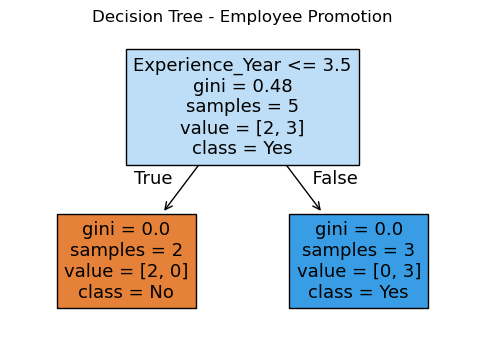

In [8]:
plt.figure(figsize=(6,4))
plot_tree(model,feature_names=['Experience_Year','Performance_Rate'],
          class_names=['No','Yes'],
          filled=True)
plt.title('Decision Tree - Employee Promotion')
plt.show()

In [9]:
exp_year=float(input('Enter Experience Years : '))
perf_rate=float(input('Enter Performance Rate : '))
promo_pred=pd.DataFrame([[exp_year, perf_rate]],columns=['Experience_Year','Performance_Rate'])
promo_pred_res=model.predict(promo_pred)
print(f'With {exp_year} years of experience and  {perf_rate} performance most likely you will be promoted: {promo_pred_res[0]}')


Enter Experience Years :  1
Enter Performance Rate :  6


With 1.0 years of experience and  6.0 performance most likely you will be promoted: No


## Example 2

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

In [11]:
data={'Age':[25,30,45,35,22,40,50],
      'Income':['Low','Medium','High','Medium','Low','High','High'],
      'Buy':['No','No','Yes','Yes','No','Yes','Yes']}

In [12]:
dfs=pd.DataFrame(data)
dfs

,Age,Income,Buy
0,25,Low,No
1,30,Medium,No
2,45,High,Yes
3,35,Medium,Yes
4,22,Low,No
5,40,High,Yes
6,50,High,Yes


In [13]:
encoder = OneHotEncoder(sparse_output=False)
income_enc = encoder.fit_transform(pd.DataFrame(dfs['Income']))
income_enc_dfs = pd.DataFrame(income_enc, columns = encoder.get_feature_names_out(['Income']))
income_enc_dfs

,Income_High,Income_Low,Income_Medium
0,0.0,1.0,0.0
1,0.0,0.0,1.0
2,1.0,0.0,0.0
3,0.0,0.0,1.0
4,0.0,1.0,0.0
5,1.0,0.0,0.0
6,1.0,0.0,0.0


In [14]:
le=LabelEncoder()
dfs['Buy']=le.fit_transform(dfs['Buy'])

In [15]:
dfs_enc = pd.concat([dfs[['Age','Buy']],income_enc_dfs],axis=1)
dfs_enc

,Age,Buy,Income_High,Income_Low,Income_Medium
0,25,0,0.0,1.0,0.0
1,30,0,0.0,0.0,1.0
2,45,1,1.0,0.0,0.0
3,35,1,0.0,0.0,1.0
4,22,0,0.0,1.0,0.0
5,40,1,1.0,0.0,0.0
6,50,1,1.0,0.0,0.0


In [16]:
X =dfs_enc.drop('Buy',axis=1)
y =dfs_enc['Buy']
X,y

(   Age  Income_High  Income_Low  Income_Medium
 0   25          0.0         1.0            0.0
 1   30          0.0         0.0            1.0
 2   45          1.0         0.0            0.0
 3   35          0.0         0.0            1.0
 4   22          0.0         1.0            0.0
 5   40          1.0         0.0            0.0
 6   50          1.0         0.0            0.0,
 0    0
 1    0
 2    1
 3    1
 4    0
 5    1
 6    1
 Name: Buy, dtype: int64)

In [17]:
model=DecisionTreeClassifier()
model.fit(X,y)

DecisionTreeClassifier()

In [18]:
sample=pd.DataFrame({'Age':[28],'Income':['High']})
sample_encoded=encoder.transform(sample[['Income']])
sample_encoded_df=pd.DataFrame(sample_encoded, columns=encoder.get_feature_names_out(['Income']))
sample_final=pd.concat([sample[['Age']],sample_encoded_df],axis=1)

prediction=model.predict(sample_final)
predicted_label = le.inverse_transform(prediction)
print('Prediction for age=28,Income=Medium ->',predicted_label[0])

Prediction for age=28,Income=Medium -> No


In [20]:
person_age = int(input('Age: '))
person_income = input('Enter Low, Medium or High: ')

# Create DataFrame for user input
person = pd.DataFrame({'Age': [person_age], 'Income': [person_income]})

# Encode the Income value
person_encoded = encoder.transform(person[['Income']])
person_encoded_df = pd.DataFrame(person_encoded, columns=encoder.get_feature_names_out(['Income']))

# Combine with Age
person_final = pd.concat([person[['Age']], person_encoded_df], axis=1)

# Predict and decode the label
prediction = model.predict(person_final)
predicted_label = le.inverse_transform(prediction)

print(f'Prediction for Age={person_age}, Income={person_income} → {predicted_label[0]}')


Age:  5
Enter Low, Medium or High:  High


Prediction for Age=5, Income=High → No


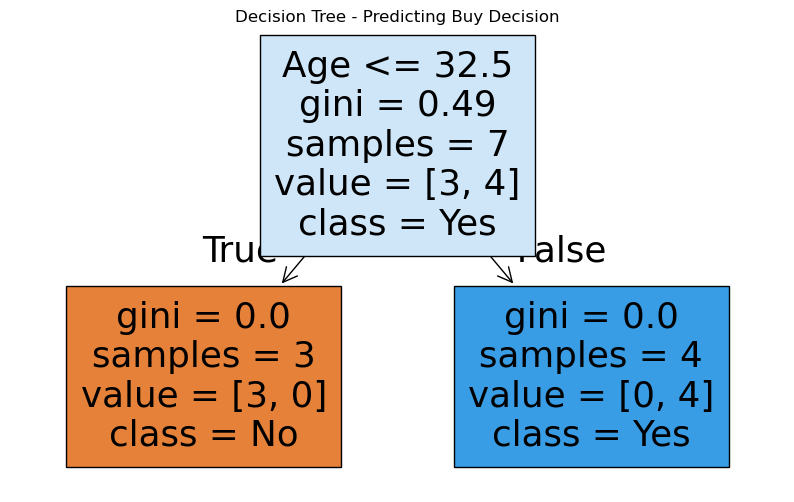

In [21]:
plt.figure(figsize=(10,6))
plot_tree(model, feature_names=X.columns, class_names=['No', 'Yes'], filled=True)
plt.title('Decision Tree - Predicting Buy Decision')
plt.show()

In [22]:
from sklearn.svm import SVC
df_spam = pd.read_csv('email_spam.csv')
print(df_spam)

df_spam_train = df_spam[df_spam['Spam']!='?']
X = df_spam_train[['Word_Frequency','Contains_Link']]
y = df_spam_train['Spam']

svm_model = SVC(kernel='linear', probability=True)
svm_model.fit(X, y)

pred_spam = svm_model.predict([[0.5,1]])
print('Spam prediction:', pred_spam[0])

   Word_Frequency  Contains_Link Spam
0             0.8              1  Yes
1             0.1              0   No
2             0.6              1  Yes
3             0.2              0   No
4             0.5              1    ?
Spam prediction: Yes


C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
